In [1]:
%matplotlib inline
import numpy as np
import torch
torch.set_printoptions(edgeitems=2,linewidth=75)

In [2]:
t_c = [0.5, 14.0, 15.0, 28.0, 11.0, 8.0, 3.0, -4.0, 6.0, 13.0, 21.0] 
t_u = [35.7, 55.9, 58.2, 81.9, 56.3, 48.9, 33.9, 21.8, 48.4, 60.4, 68.4]

In [3]:
t_c = torch.tensor(t_c)
t_u = torch.tensor(t_u)

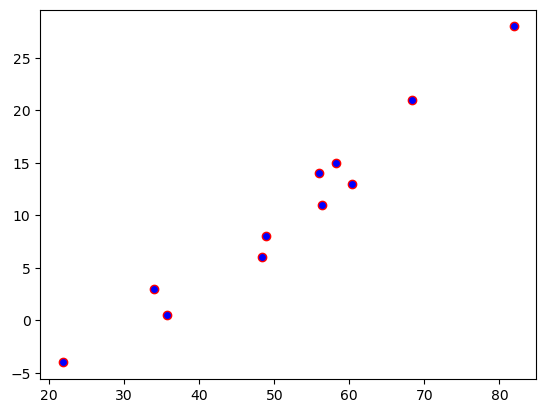

In [5]:
import matplotlib.pyplot as plt
fig = plt.figure()
plt.scatter(t_u,t_c,c='b',edgecolor='r')
plt.show()

In [6]:
def model(t_u,w,b):
    return t_u*w+b

# L1损失 
1. |t_p-t_c|
# L2损失 
1. (t_p-t_c)2

损失函数也可以叫代价函数，损失函数是用来估计模型的预测值与真实值不一样的程度。损失函数越小，模型的鲁棒性越好。

In [16]:
def loss_fn(t_p, t_c):
    squared_diff = (t_p-t_c) **2
    return squared_diff.mean()

In [17]:
w = torch.ones(())
b = torch.zeros(())
t_p = model(t_u, w, b)
t_p.shape
t_p

tensor([35.7000, 55.9000, 58.2000, 81.9000, 56.3000, 48.9000, 33.9000,
        21.8000, 48.4000, 60.4000, 68.4000])

In [12]:
w

tensor(1.)

In [18]:
loss = loss_fn(t_p, t_c)
loss

tensor(1763.8848)

In [19]:
w = torch.zeros(())
b = torch.zeros(())
t_p = model(t_u, w, b)
t_p

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [20]:
loss = loss_fn(t_p, t_c)
loss

tensor(187.3864)

# 广播机制
1. 第一条规则 ，每个tensor至少有1个维度
2. 第二条规则，当进行维度扩充的时候，从最后一个维度开始看起，然后维度要符合三种情况
    1. 连个维度的size相等，那么就进行正常的运算
    2. 其中一个维度的size为1，那么Pytorch会用这个维度上的单个项与另一个张量在这个维度上的每一项进行运算
    3. 其中一个维度不存在，也就是一个张量的维度比另一个张量多，那么另外一个张量上的所有项将和这些维度上的每一项进行运算

In [21]:
x = torch.ones(()) #产生了一个标量
y = torch.ones(3,1) #2维张量
z = torch.ones(1,3) #2维张量
a = torch.ones(2, 1, 1) #3维张量

In [22]:
x.shape

torch.Size([])

In [23]:
y.shape

torch.Size([3, 1])

In [24]:
z.shape

torch.Size([1, 3])

In [25]:
a.shape

torch.Size([2, 1, 1])

In [26]:
print("x * y", (x * y).shape)

x * y torch.Size([3, 1])


In [27]:
print("y * z", (y * z).shape)

y * z torch.Size([3, 3])


In [28]:
print("y * z * a", (y * z * a).shape)

y * z * a torch.Size([2, 3, 3])


In [29]:
x = torch.ones(5, 2, 4, 1) 
y = torch.ones(3, 1, 1) 
x + y

RuntimeError: The size of tensor a (2) must match the size of tensor b (3) at non-singleton dimension 1